# 题目10：商品评论情感分析

一家电商公司收集了大量用户对其商品的评论和用户的基本信息。为了更好地理解用户情感，并预测用户的满意度，公司希望对这些数据进行深入分析。


#### 第一部分：数据预处理与词云生成准备 (15分)

1. 导入必要库：`pandas`, `jieba`, `re`, `wordcloud`, `matplotlib.pyplot`, `numpy`。（2分）  
2. 读取模拟数据文件 `reviews.csv`（下方提供代码生成），字段为 `review_text`（评论文本）、`sentiment`（真实标签，0=负向，1=正向）。将数据存入变量 `df`。（2分）  
3. 文本清洗函数 `clean_text(text)`：  
   - 去除 URL（如 `http://...` 或 `www.xxx.com`）  
   - 去除邮箱地址  
   - 去除标点符号及特殊字符（保留中文、英文字母、数字）  
   - 去除多余空格（替换连续空格为单个空格，并去掉首尾空格）  
   （请使用 `re.sub` 完成，6分）  
4. 应用清洗函数到 `review_text` 列，生成新列 `cleaned_text`。（2分）  
5. 使用 `jieba.cut` 对 `cleaned_text` 进行精确分词，得到分词列表列 `segmented`。（3分）  


#### 第二部分：机器学习建模 (20分)

6. 导入 `sklearn` 相关模块：`train_test_split`, `TfidfVectorizer`, `MultinomialNB`, `accuracy_score`, `classification_report`。（2分）  
7. 将分词后的列表转回字符串（空格连接），用于向量化：创建列 `text_for_model` = `df['segmented'].apply(lambda x: ' '.join(x))`。（2分）  
8. 使用 `TfidfVectorizer`（参数：`max_features=5000`, `stop_words=['的','了','是','在','我','有']`）对 `text_for_model` 进行向量化。先 `fit_transform` 训练集，再 `transform` 测试集。（6分）  
9. 划分训练集（80%）与测试集（20%），随机种子设为 42。（3分）  
10. 训练 `MultinomialNB()` 模型，拟合训练数据。（3分）  
11. 在测试集上预测，并打印准确率与分类报告（precision, recall, f1-score）。（4分）  

---

#### 第三部分：情感词云可视化 (15分)

12. 根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论。（2分）  
13. 对两类评论的 `cleaned_text` 分别合并成一个大字符串。（2分）  
14. 定义函数 `generate_wordcloud(text, title, filename, colormap)`：  
    - 使用 `WordCloud` 生成词云，要求：  
      - 中文字体：`font_path='simhei.ttf'`（确保系统有该字体，或替换为 `'msyh.ttc'` 等）  
      - 背景色白色 `background_color='white'`  
      - 最大显示词数 100  
      - 使用传入的 `colormap`（如 `'Blues'` 表示冷色系，`'Reds'` 表示暖色系）  
    - 添加标题 `plt.title(title)`  
    - 保存到文件 `filename`（如 `'positive_cloud.png'`）  
    - 显示图像  
    （8分）  
15. 调用函数：  
    - 对正向评论生成词云，标题“正向情感关键词”，保存为 `"positive_cloud.png"`，色系 `'Greens'`  
    - 对负向评论生成词云，标题“负向情感关键词”，保存为 `"negative_cloud.png"`，色系 `'Reds'`  
    （3分）  

In [143]:
import pandas as pd
import random

# 模拟生成500条商品评论数据
random.seed(42)
positive_keywords = ['很好', '喜欢', '推荐', '质量不错', '物流快', '服务好', '性价比高', '超值', '满意', '惊喜']
negative_keywords = ['差评', '垃圾', '失望', '太慢', '客服差', '虚假宣传', '不值', '后悔', '破损', '异味']

reviews = []
labels = []

for _ in range(500):
    if random.random() > 0.5:
        # 正向评论
        base = f"这个商品{random.choice(positive_keywords)}，特别是物流速度非常快，客服也很耐心解答问题。虽然价格稍高，但物有所值！"
        reviews.append(base + " " + f"https://example{random.randint(1,100)}.com")
        labels.append(1)
    else:
        # 负向评论
        base = f"非常{random.choice(negative_keywords)}！物流拖了一周还没到，客服根本不理人。产品和宣传完全不符，简直是诈骗！"
        reviews.append(base + " contact@example.com")
        labels.append(0)

df_sim = pd.DataFrame({
    'review_text': reviews,
    'sentiment': labels
})
df_sim.to_csv(r'csv\reviews.csv', index=False, encoding='utf-8')
print("✅ 模拟数据 reviews.csv 已生成！")

✅ 模拟数据 reviews.csv 已生成！


读取模拟数据文件 `reviews.csv`（下方提供代码生成），字段为 `review_text`（评论文本）、`sentiment`（真实标签，0=负向，1=正向）。将数据存入变量 `df`

In [144]:
df = pd.read_csv(r'csv\reviews.csv', encoding='utf-8')

构建文本清洗函数 `clean_text(text)`：  
   - 去除 URL（如 `http://...` 或 `www.xxx.com`）  
   - 去除邮箱地址  
   - 去除标点符号及特殊字符（保留中文、英文字母、数字）  
   - 去除多余空格（替换连续空格为单个空格，并去掉首尾空格）  

In [145]:
import re

def clean_text(text):
    # 去除 url
    text = re.sub(r'https?://.*\.com|www\..*\.com', '', text)
    # 去除邮箱地址
    text = re.sub(r'\b\w*@\w*.com\b', '', text)
    # 保留中文、英文字母、数字 --- 去除标点符号
    text = re.sub(r'[，。？；‘“”’！,.?;:\'\"{}]+', '', text)
    # 去除多余空格
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    return text

应用清洗函数到 `review_text` 列，生成新列 `cleaned_text`

In [146]:
df['cleaned_text'] = df['review_text'].apply(clean_text)
df['cleaned_text'].head()

0    这个商品很好特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值
1       非常太慢物流拖了一周还没到客服根本不理人产品和宣传完全不符简直是诈骗
2       非常垃圾物流拖了一周还没到客服根本不理人产品和宣传完全不符简直是诈骗
3    这个商品满意特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值
4    这个商品很好特别是物流速度非常快客服也很耐心解答问题虽然价格稍高但物有所值
Name: cleaned_text, dtype: object

使用 `jieba.cut` 对 `cleaned_text` 进行精确分词，得到分词列表列 `segmented`

In [147]:
import jieba
def cut(text):
    return jieba.lcut(text,cut_all=False)

df['segmented'] = df['cleaned_text'].apply(cut)
df['segmented'].head()

c:\Users\xytcs\Desktop\uv_python\ds_learn\.venv\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\xytcs\AppData\Local\Temp\jieba.cache
Loading model cost 0.758 seconds.
Prefix dict has been built successfully.


0    [这个, 商品, 很, 好, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很,...
1    [非常, 太慢, 物流, 拖, 了, 一周, 还, 没到, 客服, 根本, 不理, 人, 产...
2    [非常, 垃圾, 物流, 拖, 了, 一周, 还, 没到, 客服, 根本, 不理, 人, 产...
3    [这个, 商品, 满意, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很, 耐...
4    [这个, 商品, 很, 好, 特别, 是, 物流, 速度, 非常, 快, 客服, 也, 很,...
Name: segmented, dtype: object

In [148]:
#  导入 `sklearn` 相关模块：`train_test_split`, `TfidfVectorizer`, `MultinomialNB`, `accuracy_score`, `classification_report`
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report



In [149]:
# # 将分词后的列表转回字符串（空格连接），用于向量化：创建列 `text_for_model` = `df['segmented'].apply(lambda x: ' '.join(x))`
df['text_for_model'] = df['segmented'].apply(lambda a: ' '.join(a))
df['text_for_model'].head()

0    这个 商品 很 好 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价...
1    非常 太慢 物流 拖 了 一周 还 没到 客服 根本 不理 人 产品 和 宣传 完全 不符 ...
2    非常 垃圾 物流 拖 了 一周 还 没到 客服 根本 不理 人 产品 和 宣传 完全 不符 ...
3    这个 商品 满意 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价格...
4    这个 商品 很 好 特别 是 物流 速度 非常 快 客服 也 很 耐心 解答 问题 虽然 价...
Name: text_for_model, dtype: object

In [150]:
x_train, x_test, y_train, y_test = train_test_split(df['text_for_model'], df['sentiment'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, stop_words=['的','了','是','在','我','有'])
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)



nomialnb = MultinomialNB()
nomialnb.fit(x_train, y_train)
y_pred = nomialnb.predict(x_test)

print(f"准确率: {accuracy_score(y_test, y_pred)}")
print("分类报告:")
print(classification_report(y_test, y_pred))



准确率: 1.0
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        54

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [151]:
#  根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论
index = y_test.index
df['pred_sentiment'] = df['sentiment']
df.loc[index, 'pred_sentiment'] = y_pred

postive = ' '.join(df.loc[df['pred_sentiment'] == 1, 'cleaned_text'].to_list())
negative = ' '.join(df.loc[df['pred_sentiment'] == 0, 'cleaned_text'].to_list())

In [152]:
import wordcloud
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

def generate_wordcloud(text, title, filename, colormap):
    wc = wordcloud.WordCloud(font_path='simhei.ttf',
                             background_color='white',
                             max_words=100,
                             colormap=colormap,
                             )
    word_cloud = wc.generate(text)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis('off')
    plt.savefig(filename)
    plt.show()



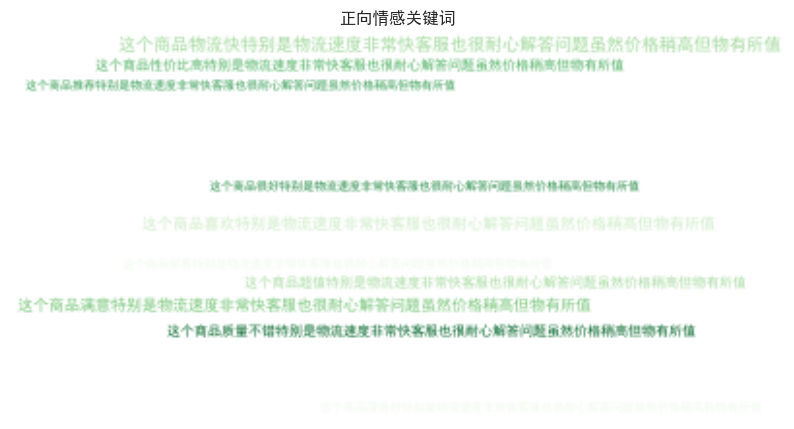

In [153]:
generate_wordcloud(postive, '正向情感关键词', r'png/positive_cloud.png', colormap='Greens')

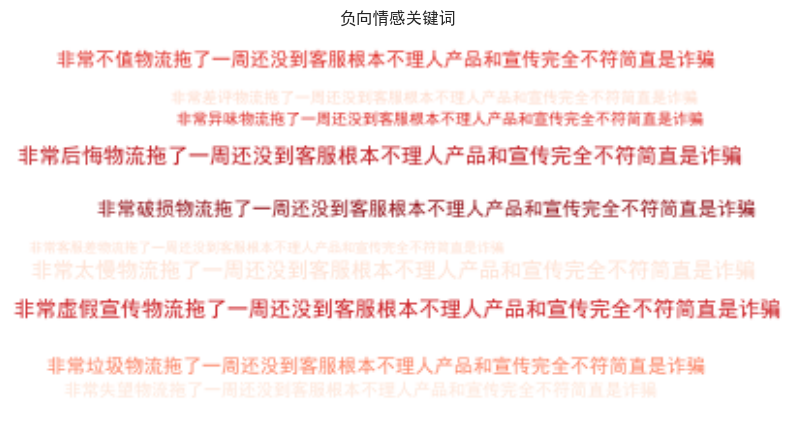

In [154]:
generate_wordcloud(negative, '负向情感关键词', r'png/negative_cloud.png', colormap='Reds')

12. 根据模型预测结果（非真实标签），筛选出预测为正向（1）和负向（0）的评论。（2分）  
13. 对两类评论的 `cleaned_text` 分别合并成一个大字符串。（2分）  
14. 定义函数 `generate_wordcloud(text, title, filename, colormap)`：  
    - 使用 `WordCloud` 生成词云，要求：  
      - 中文字体：`font_path='simhei.ttf'`（确保系统有该字体，或替换为 `'msyh.ttc'` 等）  
      - 背景色白色 `background_color='white'`  
      - 最大显示词数 100  
      - 使用传入的 `colormap`（如 `'Blues'` 表示冷色系，`'Reds'` 表示暖色系）  
    - 添加标题 `plt.title(title)`  
    - 保存到文件 `filename`（如 `'positive_cloud.png'`）  
    - 显示图像  
    （8分）  
15. 调用函数：  
    - 对正向评论生成词云，标题“正向情感关键词”，保存为 `"positive_cloud.png"`，色系 `'Greens'`  
    - 对负向评论生成词云，标题“负向情感关键词”，保存为 `"negative_cloud.png"`，色系 `'Reds'`  
    （3分）  

# 题目 11： 自动化文档处理

使用 Python 读取并自动化处理一份包含表格和段落的 Word 文档，完成内容提取、修改、统计与格式化保存。

【任务】  

1. 使用合适的命令导入 `python-docx` 库（2分）  
   - 要求：仅导入必要模块，禁止导入未使用的库

2. 打开【data_A】文件夹中的【2024年销售季度报告.docx】文档，遍历并打印所有**非空段落**的文本内容（4分）  
   - 提示：跳过 text 为空的段落（如仅有换行或空白字符）

3. 统计并按格式打印：
   - 文档总段落数（含空段落）
   - 非空段落数
   - 总字符数（含标点、数字、空格）
   - 表格总数
   - 所有表格中单元格总数（5分）  
   【参考打印格式】  
   ```
   总段落数: []
   非空段落数: []
   总字符数: []
   表格总数: []
   单元格总数: []
   ```

4. 将文档中所有出现的“销售额”替换为“Revenue（销售额）”，要求在保留原格式（加粗/斜体）前提下替换（6分）  
   - 注意：不能直接替换整个段落.text，需遍历每个 `Run` 对象进行局部替换
   - 替换后打印所有被修改段落的完整文本（用于验证）

5. 在**每张表格下方插入新段落**，内容为：“表 [n]：数据来源内部系统”，其中 n 为当前表格序号（从1开始）；该段落字体加粗、居中对齐（7分）  
   - 要求：使用 `WD_ALIGN_PARAGRAPH.CENTER` 设置对齐方式
   - 要求：使用 `bold = True` 设置加粗

6. 在文档末尾添加标题“附录：数据汇总”，级别为 level=1，并紧接着添加一个 3×4 的空表格（列名：项目、Q1、Q2、Q3），设置第一行为灰色底纹（RGB(200,200,200)）（8分）  
   - 提示：使用 `add_heading`, `add_table`, `rows[0].cells[i]._element.get_or_add_tcPr().append(...)` 设置背景色

7. 将最终处理后的文档另存为【output_A】文件夹中的【2024_销售报告_修订版.docx】（4分）  

8. 每完成一个主要任务（第2～6问）后，打印一行由 50 个 “=” 组成的分隔线（如：==================================================）以划分输出区块（4分）

【备注】  
- 正确输出结构可参考【refer_A/第五题.txt】文件。
- 原始文档包含3个表格、若干带格式段落、部分段落含“销售额”关键词。
- 表格内可能也包含“销售额”文字，但也需要被替换。
- 替换时若原文本加粗，“Revenue（销售额）”也必须保持加粗。

【加分挑战】 ✅  
- 若能在替换“销售额”时，自动记录替换次数并在最后打印：“共执行 [x] 处文本替换”，额外加3分。

In [155]:
# 模拟数据生成

from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

# 创建模拟文档用于练习
doc = Document()

# 添加标题与带格式段落
doc.add_heading('2024年第一季度销售总结', level=1)
p1 = doc.add_paragraph()
p1.add_run('本季度 ').bold = True
p1.add_run('销售额').italic = True
p1.add_run(' 同比增长15%。')

p2 = doc.add_paragraph('华东区销售额最高，其次是华南区。')
p2.alignment = WD_ALIGN_PARAGRAPH.RIGHT

doc.add_paragraph()  # 空段落

# 添加第一个表格
table1 = doc.add_table(rows=3, cols=3)
table1.style = 'Table Grid'
headers = ["区域", "销售额", "增长率"]
for i, header in enumerate(headers):
    table1.cell(0, i).text = header
    table1.cell(0, i).paragraphs[0].runs[0].bold = True
table1.cell(1, 0).text = "华东"
table1.cell(1, 1).text = "¥500万"
table1.cell(1, 2).text = "15%"
table1.cell(2, 0).text = "华南"
table1.cell(2, 1).text = "¥420万"
table1.cell(2, 2).text = "12%"

# 添加第二个表格略...

doc.add_paragraph('年度销售额目标已调整为 ¥3000万。').italic = True

# 保存原始文档
doc.save('docx/2024年销售季度报告.docx')
print("✅ 模拟文档已生成于 data_A/2024年销售季度报告.docx")


✅ 模拟文档已生成于 data_A/2024年销售季度报告.docx


In [156]:
import docx

doc = docx.Document(r'docx\2024年销售季度报告.docx')

paragraphs = doc.paragraphs
nonan_para = 0

char_num = 0
for paragraph in paragraphs:
    if paragraph.text.strip() != '':
        print(paragraph.text)
        char_num += len(paragraph.text)
    else:
        continue
        
    nonan_para += 1

ele_num = 0
for table in doc.tables:
    ele_num += len(table.rows) * len(table.columns)


2024年第一季度销售总结
本季度 销售额 同比增长15%。
华东区销售额最高，其次是华南区。
年度销售额目标已调整为 ¥3000万。


In [157]:
print(f"""
总段落数: [{len(paragraphs)}]
非空段落数: [{nonan_para}]
总字符数: [{char_num}]
表格总数: [{len(doc.tables)}]
单元格总数: [{ele_num}]
""")


总段落数: [5]
非空段落数: [4]
总字符数: [64]
表格总数: [1]
单元格总数: [9]



将文档中所有出现的“销售额”替换为“Revenue（销售额）”，要求在保留原格式（加粗/斜体）前提下替换（6分）  
   - 注意：不能直接替换整个段落.text，需遍历每个 `Run` 对象进行局部替换
   - 替换后打印所有被修改段落的完整文本（用于验证）

In [158]:
for paragraph in paragraphs:
    for run in paragraph.runs:
        if "销售额" in run.text:
            run.text = run.text.replace("销售额", "Revenue（销售额）")
        
            print(paragraph.text)

本季度 Revenue（销售额） 同比增长15%。
华东区Revenue（销售额）最高，其次是华南区。
年度Revenue（销售额）目标已调整为 ¥3000万。


在**每张表格下方插入新段落**，内容为：“表 [n]：数据来源内部系统”，其中 n 为当前表格序号（从1开始）；该段落字体加粗、居中对齐（7分）  
   - 要求：使用 `WD_ALIGN_PARAGRAPH.CENTER` 设置对齐方式
   - 要求：使用 `bold = True` 设置加粗

将最终处理后的文档另存为【output_A】文件夹中的【2024_销售报告_修订版.docx】

In [159]:
doc.save(r"docx/2024_销售报告_修订版.docx")

In [160]:
def traverse_tables(doc_path: str):
    """遍历文档中的所有表格"""
    doc = Document(doc_path)
    
    print("=" * 50)
    print("📊 表格遍历")
    print("=" * 50)
    
    for table_idx, table in enumerate(doc.tables, 1):
        print(f"\n📋 表格 {table_idx}:")
        print(f"   行数: {len(table.rows)}")
        print(f"   列数: {len(table.columns)}")
        
        # 遍历所有行
        for row_idx, row in enumerate(table.rows, 1):
            print(f"\n   📍 第 {row_idx} 行:")
            
            # 遍历行中的所有单元格
            for cell_idx, cell in enumerate(row.cells, 1):
                cell_text = cell.text.strip()
                print(f"      📦 单元格[{row_idx},{cell_idx}]: '{cell_text}'")
                
                # 遍历单元格中的段落（单元格内可能有多个段落）
                if cell.paragraphs:
                    for para_idx, para in enumerate(cell.paragraphs, 1):
                        if para.text.strip():  # 只显示非空段落
                            print(f"        段落 {para_idx}: '{para.text}'")

traverse_tables(r"docx/2024_销售报告_修订版.docx")

📊 表格遍历

📋 表格 1:
   行数: 3
   列数: 3

   📍 第 1 行:
      📦 单元格[1,1]: '区域'
        段落 1: '区域'
      📦 单元格[1,2]: '销售额'
        段落 1: '销售额'
      📦 单元格[1,3]: '增长率'
        段落 1: '增长率'

   📍 第 2 行:
      📦 单元格[2,1]: '华东'
        段落 1: '华东'
      📦 单元格[2,2]: '¥500万'
        段落 1: '¥500万'
      📦 单元格[2,3]: '15%'
        段落 1: '15%'

   📍 第 3 行:
      📦 单元格[3,1]: '华南'
        段落 1: '华南'
      📦 单元格[3,2]: '¥420万'
        段落 1: '¥420万'
      📦 单元格[3,3]: '12%'
        段落 1: '12%'


# 题目11：数据清洗

处理一个包含客户交易信息的CSV文件（customer_transactions.csv），针对不同列的缺失值进行填充操作。填充的方式包括使用特定方法填充某些列，使用条件填充某些特定的情况，最后将处理后的数据保存为新的CSV文件。

【任务】  
1. 导入Pandas库，并读取【data_A】目录下的【customer_transactions.csv】表格数据，将读取的结果存储在变量df中（4分）
2. 针对交易日期（transaction_date）列的缺失值，使用该列的众数进行填充（4分）
3. 针对客户名称（customer_name）列的缺失值，使用该列的上一个有效值填充下一个缺失值（4分）
4. 针对金额（amount）列，当订单状态（order_status）为"completed"时，如果该金额为空，则用该客户的平均交易金额（不包含缺失值）填充；否则用0填充（5分）
5. 针对支付方式（payment_method）列的缺失值，如果该客户的其他记录中有支付方式，则使用该支付方式填充；否则填充为"unknown"（5分）
6. 将填充后的数据保存为output_A文件夹下的filled_customer_transactions.csv文件，要求不保存DataFrame的index索引，且在Excel中打开不会出现中文乱码（6分）

In [161]:
import pandas as pd

In [162]:
df = pd.read_csv('csv/customer_transactions.csv', encoding='utf-8')

df['transaction_date'] = df['transaction_date'].fillna(df['transaction_date'].mode()[0])

df['customer_name'] = df['customer_name'].ffill(axis=0)

amount_mean = df.groupby('customer_name')['amount'].mean().fillna(0)
def fill_amount(data):
    if pd.isna(data['amount']) and data['order_status'] == 'completed':
        return amount_mean.get(data['customer_name'], 0)
    elif pd.isna(data['amount']):
        return 0
    return data['amount']
    
df['amount'] = df.apply(fill_amount, axis=1)
print(df['amount'].info(), '\n')




KeyError: 'transaction_date'

In [ ]:
# 针对支付方式（payment_method）列的缺失值，如果该客户的其他记录中有支付方式，则使用该支付方式填充；否则填充为"unknown"


pay_method = df.groupby('customer_name')['payment_method'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)

pay_method = pay_method.to_dict()

def fill_payment_method(data):
    if pd.isna(data['payment_method']):
        return pay_method.get(data['customer_name'], 'unknown')

    return data['payment_method']

df['payment_method'] = df.apply(fill_payment_method, axis=1)

df['payment_method'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 200 entries, 0 to 199
Series name: payment_method
Non-Null Count  Dtype 
--------------  ----- 
200 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [ ]:
df.to_csv(r"csv/filled_customer_transactions.csv", index=False, encoding='utf-8')

# 题目 11：

你手头有一份模拟的产品销售数据 product_sales.csv，记录了不同产品的销售情况。现在，你需要对这份数据进行整理、分析，并以图表的形式直观地展示关键业务指标，以洞察各产品品类的销售表现。

*   `ProductID`: 产品唯一标识符
*   `Category`: 产品所属品类 (如: '电子产品', '家居用品', '服装鞋帽')
*   `Price`: 产品单价 (元)
*   `UnitsSold`: 已售数量
*   `Rating`: 用户评分 (1-5分)

1.  **环境准备**:
    *   导入 `pandas` 库，并简写为 `pd`。
    *   导入 `matplotlib.pyplot` 库，并简写为 `plt`。
    *   设置 Matplotlib 以正确显示中文和负号。

2.  **数据生成与读取**:
    *   运行下方提供的 **“示例数据生成代码”**，生成 `product_sales.csv` 文件。
    *   使用 pandas 读取 `product_sales.csv` 文件到名为 `df` 的 DataFrame 中。

3.  **数据清洗**:
    *   数据中可能存在 `Price` 或 `UnitsSold` 为负数或零的无效记录，请删除这些行。

4.  **探索性分析与可视化**:
    *   **价格分布**: 使用**直方图 (Histogram)** 展示清洗后产品 `Price` 的分布情况，将图形划分为 20 个区间（bins）。
    *   **价格与评分关系**: 使用**散点图 (Scatter Plot)** 探究产品 `Price` 与 `Rating` 之间的关系。要求：数据点颜色为 `green`，形状为 `o`。

5.  **业务指标计算**:
    *   新增一列 `Revenue` (销售额)，其值为 `Price` 与 `UnitsSold` 的乘积。
    *   按 `Category` (产品品类) 分组，计算每个品类的**总销售额 (Total Revenue)** 和**平均评分 (Average Rating)**。将结果存储在新的 DataFrame `category_summary` 中并打印输出。

6.  **分析结果可视化**:
    *   基于第 5 步计算出的 `category_summary`，使用**条形图 (Bar Chart)** 可视化各产品品类的总销售额。
    *   **要求**:
        *   图表标题为“各品类产品总销售额对比”。
        *   X 轴标签为“产品品类”。
        *   Y 轴标签为“总销售额 (元)”。
        *   按销售额对条形图进行**降序**排列，以便更清晰地看出销售表现。

In [ ]:
import pandas as pd
import numpy as np
# 设置随机种子以保证结果可复现
np.random.seed(42)
# 创建模拟数据
data = {
    'ProductID': range(1001, 1201),
    'Category': np.random.choice(['电子产品', '家居用品', '服装鞋帽', '图书音像'], 200),
    'Price': np.round(np.random.lognormal(mean=4.5, sigma=1.0, size=200), 2),
    'UnitsSold': np.random.randint(10, 500, size=200),
    'Rating': np.round(np.random.uniform(1.0, 5.0, size=200), 1)
}
df_gen = pd.DataFrame(data)
# 制造一些异常数据
df_gen.loc[5, 'Price'] = -150.00
df_gen.loc[10, 'UnitsSold'] = 0
df_gen.loc[15, 'Price'] = 0
# 保存到 CSV 文件
df_gen.to_csv(r'csv\product_sales.csv', index=False)
print("示例数据 'product_sales.csv' 已成功生成。")

示例数据 'product_sales.csv' 已成功生成。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme('notebook')

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_csv(r'csv\product_sales.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ProductID  200 non-null    int64  
 1   Category   200 non-null    object 
 2   Price      200 non-null    float64
 3   UnitsSold  200 non-null    int64  
 4   Rating     200 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB


In [ ]:
df = df.drop(df[(df['Price'] <= 0) | (df['UnitsSold'] <= 0)].index, axis=0)
df[['Price', 'UnitsSold']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 197 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      197 non-null    float64
 1   UnitsSold  197 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.6 KB


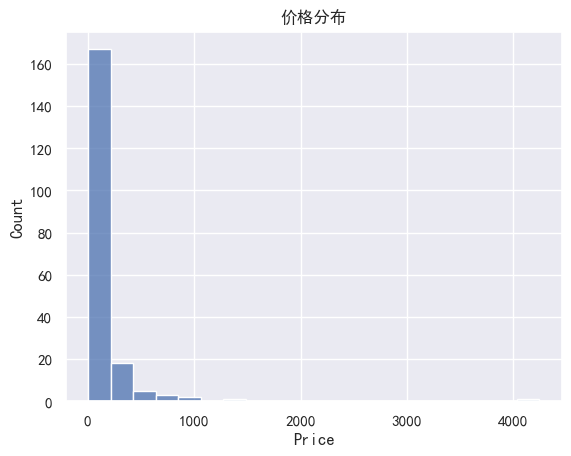

In [ ]:
sns.histplot(data=df, x='Price', bins=20)

plt.title("价格分布")
plt.show()

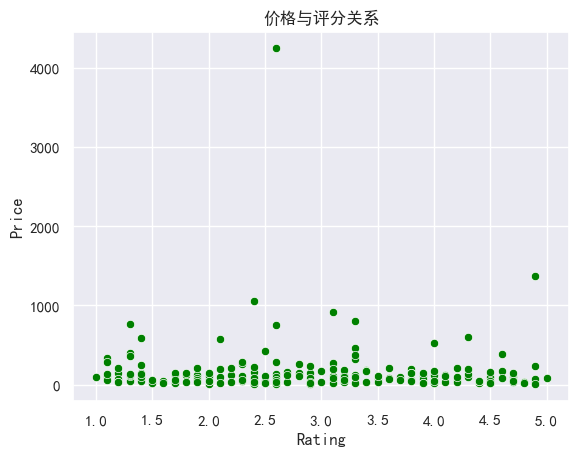

In [ ]:
sns.scatterplot(data=df, x='Rating', y='Price', markers='o', color='green')


plt.title("价格与评分关系")
plt.show()

In [ ]:
df['Revenue'] = df['Price'] * df['UnitsSold']
category_summary = df.groupby('Category')[['Revenue', 'Rating']].agg(Total_Revenue=('Revenue', 'sum'), 
                                                           Average_Rating=('Rating', 'mean'))

category_summary.head()

,Total_Revenue,Average_Rating
Category,,
图书音像,1872001.82,2.790566
家居用品,1408832.83,3.221739
服装鞋帽,1542059.59,2.815094
电子产品,2692957.24,2.926667


Text(0, 0.5, '总销售额 (元)')

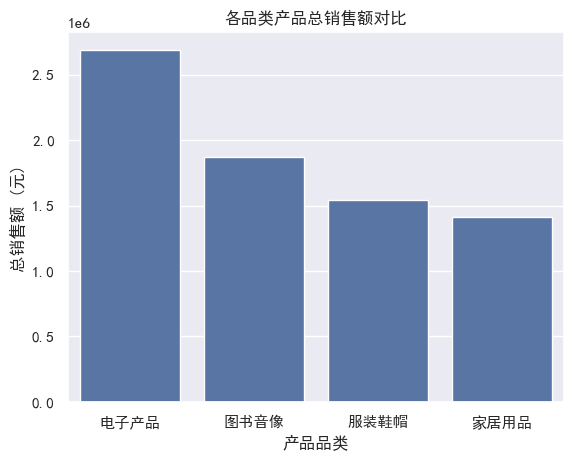

In [ ]:
category_summary = category_summary.sort_values(by='Total_Revenue', ascending=False)

sns.barplot(data=category_summary, x='Category', y='Total_Revenue')

plt.title("各品类产品总销售额对比")
plt.xlabel("产品品类")
plt.ylabel("总销售额 (元)")

1.  **环境准备**:
    *   导入 `pandas` 库，并简写为 `pd`。
    *   导入 `matplotlib.pyplot` 库，并简写为 `plt`。
    *   设置 Matplotlib 以正确显示中文和负号。

2.  **数据生成与读取**:
    *   运行下方提供的 **“示例数据生成代码”**，生成 `product_sales.csv` 文件。
    *   使用 pandas 读取 `product_sales.csv` 文件到名为 `df` 的 DataFrame 中。

3.  **数据清洗**:
    *   数据中可能存在 `Price` 或 `UnitsSold` 为负数或零的无效记录，请删除这些行。

4.  **探索性分析与可视化**:
    *   **价格分布**: 使用**直方图 (Histogram)** 展示清洗后产品 `Price` 的分布情况，将图形划分为 20 个区间（bins）。
    *   **价格与评分关系**: 使用**散点图 (Scatter Plot)** 探究产品 `Price` 与 `Rating` 之间的关系。要求：数据点颜色为 `green`，形状为 `o`。

5.  **业务指标计算**:
    *   新增一列 `Revenue` (销售额)，其值为 `Price` 与 `UnitsSold` 的乘积。
    *   按 `Category` (产品品类) 分组，计算每个品类的**总销售额 (Total Revenue)** 和**平均评分 (Average Rating)**。将结果存储在新的 DataFrame `category_summary` 中并打印输出。

6.  **分析结果可视化**:
    *   基于第 5 步计算出的 `category_summary`，使用**条形图 (Bar Chart)** 可视化各产品品类的总销售额。
    *   **要求**:
        *   图表标题为“各品类产品总销售额对比”。
        *   X 轴标签为“产品品类”。
        *   Y 轴标签为“总销售额 (元)”。
        *   按销售额对条形图进行**降序**排列，以便更清晰地看出销售表现。

# 题目 12: 综合运用 DataFrame 合并、透视表与复杂转换，分析零售店销售与库存数据

1. 创建两个 DataFrame：  
   `orders`（订单数据）：包含字段 `订单号`、`商品ID`、`年份`、`销量`、`单价`  
   `inventory`（库存数据）：包含字段 `商品ID`、`类别`、`库存数量`

2. 使用 `merge()` 将 `orders` 与 `inventory` 按 “商品ID” 进行内连接，生成 `orders_with_inv`（保留所有列），打印 `orders_with_inv`。

3. 新增 “销售额” 列（销量 × 单价，保留 1 位小数），并按 “年份” 和 “类别” 分组，计算每组的总销量和总销售额（保留 1 位小数），打印结果。

4. 使用 `pivot_table()` 创建透视表 `pivot_sales`，行索引为 “年份”，列索引为 “类别”，值为 “总销售额”，聚合函数为 `sum`，缺失值用 0 填充，打印结果。

5. 从透视表中筛选出 “电子产品” 类别在 2024 年的总销售额，并计算该值占 2024 年总销售额的比例（保留 2 位小数），打印结果。


In [ ]:
import pandas as pd

# 订单数据
data_orders = [
    ['ORD001', 'A商品', 2023, 100, 59.9],
    ['ORD002', 'B商品', 2023, 50, 89.9],
    ['ORD003', 'A商品', 2024, 150, 59.9],
    ['ORD004', 'C商品', 2024, 80, 129.9],
    ['ORD005', 'B商品', 2024, 70, 89.9]
]

columns_orders = ['订单号', '商品ID', '年份', '销量', '单价']

# 库存数据
data_inv = [
    ['A商品', '电子产品', 300],
    ['B商品', '家居用品', 200],
    ['C商品', '电子产品', 150],
    ['D商品', '户外用品', 100]
]

columns_inv = ['商品ID', '类别', '库存数量']

In [ ]:
orders = pd.DataFrame(data=data_orders, columns=columns_orders)
inventory = pd.DataFrame(data=data_inv, columns=columns_inv)

orders_with_inv = pd.merge(orders, inventory, how='inner', on='商品ID')

orders_with_inv

,订单号,商品ID,年份,销量,单价,类别,库存数量
0,ORD001,A商品,2023,100,59.9,电子产品,300
1,ORD002,B商品,2023,50,89.9,家居用品,200
2,ORD003,A商品,2024,150,59.9,电子产品,300
3,ORD004,C商品,2024,80,129.9,电子产品,150
4,ORD005,B商品,2024,70,89.9,家居用品,200


In [ ]:
orders_with_inv['销售额'] = (orders_with_inv['销量'] * orders_with_inv['单价']).round(1)


In [ ]:

pivot_sales = pd.pivot_table(data=orders_with_inv, columns='类别', index='年份', values='销售额', aggfunc='sum', fill_value=0)
pivot_sales

类别,家居用品,电子产品
年份,,
2023,4495.0,5990.0
2024,6293.0,19377.0


In [ ]:
print(pivot_sales.loc[2024, '电子产品'])
print(((pivot_sales.loc[2024, '电子产品']) / ( pivot_sales.loc[2024, :].sum())).round(2))

19377.0
0.75


1. 创建两个 DataFrame：  
   `orders`（订单数据）：包含字段 `订单号`、`商品ID`、`年份`、`销量`、`单价`  
   `inventory`（库存数据）：包含字段 `商品ID`、`类别`、`库存数量`

2. 使用 `merge()` 将 `orders` 与 `inventory` 按 “商品ID” 进行内连接，生成 `orders_with_inv`（保留所有列），打印 `orders_with_inv`。

3. 新增 “销售额” 列（销量 × 单价，保留 1 位小数），并按 “年份” 和 “类别” 分组，计算每组的总销量和总销售额（保留 1 位小数），打印结果。

4. 使用 `pivot_table()` 创建透视表 `pivot_sales`，行索引为 “年份”，列索引为 “类别”，值为 “总销售额”，聚合函数为 `sum`，缺失值用 0 填充，打印结果。

5. 从透视表中筛选出 “电子产品” 类别在 2024 年的总销售额，并计算该值占 2024 年总销售额的比例（保留 2 位小数），打印结果。


# 题目 13: 数据标准化分组统计

In [ ]:
import pandas as pd
import numpy as np

# 生成模拟数据
np.random.seed(42)

# 定义一些示例值
regions = ['North', 'South', 'East', 'West']
products = ['Product A', 'Product B', 'Product C']
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# 生成数据
data = {
    'region': np.random.choice(regions, size=100),
    'product': np.random.choice(products, size=100),
    'quarter': np.random.choice(quarters, size=100),
    'sales': np.random.uniform(1000, 50000, size=100).round(2),
    'profit': np.random.uniform(-1000, 10000, size=100).round(2)
}

sales_df = pd.DataFrame(data)
sales_df.to_csv('csv/data.csv', index=False)

# 打印生成的数据
print(sales_df.head())


  region    product quarter     sales   profit
0   East  Product C      Q4   8385.16  8335.37
1   West  Product B      Q4  25901.74   502.83
2  North  Product B      Q4  35094.83  6798.02
3   East  Product B      Q4  43059.58  5081.02
4   East  Product B      Q4  16971.99  2261.61


对数据进行标准化处理，并结合分组操作进行统计分析。
【任务】  
1.读取文件`data.csv`中的销售数据到 DataFrame 对象 `sales_df`并打印（4分）   
2.对`sales`和`profit`列进行 min-max 标准化（将值映射到 [0,1] 范围），打印结果（7 分）  
3.按`region`分组，计算每个地区的总销售额和总利润，打印结果（5 分）  
4.按`product`和`quarter`分组，计算每组的平均销售额和平均利润率（利润率 = `profit/sales`），打印结果（7 分）

In [ ]:
sales_df = pd.read_csv('csv/data.csv')

In [ ]:
def min_max(data:pd.Series):
    max_value = data.max()
    min_value = data.min()

    return data.apply(lambda x: (x - min_value) / (max_value - min_value))

tmp_df = sales_df[['sales', 'profit']].apply(min_max, axis=0)
tmp_df

,sales,profit
0,0.135601,0.863646
1,0.501057,0.134578
2,0.692857,0.720547
3,0.859029,0.560725
4,0.314752,0.298289
...,...,...
95,0.667637,0.581763
96,0.348169,0.126263
97,0.241355,0.825285
98,0.283400,0.834945


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
tmp = scaler.fit_transform(sales_df[['profit', 'sales']])
sales_df['sales_scaler'] = tmp[:, 1]
sales_df['profit_scaler'] = tmp[:, 0]

sales_df[['sales_scaler', 'profit_scaler']]


,sales_scaler,profit_scaler
0,0.135601,0.863646
1,0.501057,0.134578
2,0.692857,0.720547
3,0.859029,0.560725
4,0.314752,0.298289
...,...,...
95,0.667637,0.581763
96,0.348169,0.126263
97,0.241355,0.825285
98,0.283400,0.834945


In [ ]:
sales_df.groupby('region')[['sales', 'profit']].sum()

,sales,profit
region,,
East,669510.02,118083.85
North,683145.81,88134.23
South,569700.17,98337.00
West,844477.54,116845.95


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   region   100 non-null    object 
 1   product  100 non-null    object 
 2   quarter  100 non-null    object 
 3   sales    100 non-null    float64
 4   profit   100 non-null    float64
dtypes: float64(2), object(3)
memory usage: 4.0+ KB


In [ ]:
sales_df['p_profit'] = sales_df['profit'] / sales_df['sales']

sales_df.groupby(by=['product', 'quarter'])[['sales', 'p_profit']].mean()

sales  p_profit
product   quarter                        
Product A Q1       25676.475556  0.178426
          Q2       26414.890000  0.178104
          Q3       31632.381250  0.198959
          Q4       28702.524545  0.365060
Product B Q1       23653.620000  0.244184
          Q2       23225.723000  0.242073
          Q3       24488.184000  0.233609
          Q4       28330.061667  0.429727
Product C Q1       26602.611818  0.200473
          Q2       24216.795714  0.100318
          Q3       35172.061111  0.150631
          Q4       30034.395000  0.258440

对数据进行标准化处理，并结合分组操作进行统计分析。
【任务】  
1.读取文件`data.csv`中的销售数据到 DataFrame 对象 `sales_df`并打印（4分）   
2.对`sales`和`profit`列进行 min-max 标准化（将值映射到 [0,1] 范围），打印结果（7 分）  
3.按`region`分组，计算每个地区的总销售额和总利润，打印结果（5 分）  
4.按`product`和`quarter`分组，计算每组的平均销售额和平均利润率（利润率 = `profit/sales`），打印结果（7 分）

# 题目 13： 读取多个 Excel 工作表数据，合并后进行复杂分组聚合，生成多维度统计指标。

In [ ]:
import pandas as pd
import numpy as np

# 创建员工数据
np.random.seed(42)
employee_ids = range(1, 101)
departments = ["销售", "研发", "市场", "人力资源"] * 25
genders = ["男", "女"] * 50
hire_years = np.random.randint(2010, 2024, size=100)
positions = ["经理", "主管", "员工"] * 33 + ["员工"]

emp_df = pd.DataFrame({
    'employee_id': employee_ids,
    'department': departments,
    'gender': genders,
    'hire_year': hire_years,
    'position': positions
})

# 创建薪资数据
years = [2021, 2022, 2023]
salary_data = []
for year in years:
    salaries = np.random.randint(50000, 200000, size=100).astype(float)
    data = pd.DataFrame({
        'employee_id': employee_ids,
        'year': [year] * 100,
        'salary': salaries
    })
    salary_data.append(data)

sal_df = pd.concat(salary_data)

# 创建评分数据
rating_data = []
for year in years:
    ratings = np.random.uniform(1.0, 5.0, size=100).round(2)
    data = pd.DataFrame({
        'employee_id': employee_ids,
        'year': [year] * 100,
        'rating': ratings
    })
    rating_data.append(data)

perf_df = pd.concat(rating_data)

# 将各个数据表写入到一个 Excel 文件中
with pd.ExcelWriter('csv/sample_data.xlsx') as writer:
    emp_df.to_excel(writer, sheet_name='employees', index=False)
    sal_df.to_excel(writer, sheet_name='salaries', index=False)
    perf_df.to_excel(writer, sheet_name='performance', index=False)

print("文件已成功写入到: csv/sample_data.xlsx")


文件已成功写入到: csv/sample_data.xlsx


1. 分别读取 3 个工作表数据，命名为 `emp_df`, `sal_df`, `perf_df`，分别打印3个数据框（6 分）。
2. 将 3 个 DataFrame 按 “员工 ID” 合并为 `combined_df`，打印结果（6 分）。

3. 按 “部门” 和 “性别” 分组，计算并打印： 
   - (1) 各部门男女员工的平均年薪（2023 年）（4 分）
   - (2) 各部门男女员工的平均绩效评分（2023 年）（4 分）

4. 按 “入职年份” 和 “职位” 分组，计算并打印： 
   - (1) 每组员工的薪资增长率（（2023-2021）/2021）（5 分）
   - (2) 每组员工的绩效提升幅度（2023-2021）（5分）



| 数据文件     | 字段            | 描述                              |
|--------------|-----------------|-----------------------------------|
| employees    | employee_id     | 员工 ID                          |
|              | department      | 部门                             |
|              | gender          | 性别                             |
|              | hire_year       | 入职年份                         |
|              | position        | 职位                             |
| salaries     | employee_id     | 员工 ID                          |
|              | year            | 年份                             |
|              | salary          | 年薪                             |
| performance  | employee_id     | 员工 ID                          |
|              | year            | 年份                             |
|              | rating          | 绩效评分                         |


In [ ]:
emp_df = pd.read_excel('csv/sample_data.xlsx', sheet_name='employees')
sal_df = pd.read_excel('csv/sample_data.xlsx', sheet_name='salaries')
perf_df = pd.read_excel('csv/sample_data.xlsx', sheet_name='performance')

In [ ]:
combined_df = pd.merge(emp_df, sal_df, on='employee_id', how='inner').merge(perf_df, on=['employee_id', 'year'], how='inner')
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  300 non-null    int64  
 1   department   300 non-null    object 
 2   gender       300 non-null    object 
 3   hire_year    300 non-null    int64  
 4   position     300 non-null    object 
 5   year         300 non-null    int64  
 6   salary       300 non-null    int64  
 7   rating       300 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
combined_df[combined_df['year'] == 2023].groupby(["department", "gender"])[['salary', 'rating']].mean()

,,salary,rating
department,gender,,
人力资源,女,135438.24,2.9828
市场,男,120749.72,2.8800
研发,女,130384.84,2.9984
销售,男,123098.60,2.9036


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  300 non-null    int64  
 1   department   300 non-null    object 
 2   gender       300 non-null    object 
 3   hire_year    300 non-null    int64  
 4   position     300 non-null    object 
 5   year         300 non-null    int64  
 6   salary       300 non-null    int64  
 7   rating       300 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.groupby()[['', '', '']]

In [ ]:
salpivot_df = pd.pivot_table(data=sal_df, columns='year', index='employee_id', values='salary', aggfunc='sum')
salpivot_df['salary_up'] = (salpivot_df[2023] - salpivot_df[2021]) / salpivot_df[2021]


perfpivot_df = pd.pivot_table(data=perf_df, values='rating', columns='year', index='employee_id', aggfunc='sum')
perfpivot_df['perf_up'] = (perfpivot_df[2023] - perfpivot_df[2021])

combined_df = emp_df.merge(salpivot_df[['salary_up']], on='employee_id', how='left').merge(perfpivot_df[['perf_up']], on=['employee_id'], how='left')
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  100 non-null    int64  
 1   department   100 non-null    object 
 2   gender       100 non-null    object 
 3   hire_year    100 non-null    int64  
 4   position     100 non-null    object 
 5   salary_up    100 non-null    float64
 6   perf_up      100 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 5.6+ KB


In [ ]:
combined_df.groupby(['hire_year', 'position'])[['salary_up', 'perf_up']].mean()

salary_up   perf_up
hire_year position                     
2010      员工        -0.017340  0.060000
          经理        -0.683893 -0.020000
2011      主管         0.236834  0.216667
          员工        -0.294586  2.075000
          经理         0.167816 -0.540000
2012      主管        -0.392445 -1.870000
          员工         0.069052  0.820000
          经理        -0.398317 -0.210000
2013      主管         1.381598 -0.185000
          员工         0.095929 -2.190000
          经理         0.032743 -0.781667
2014      主管        -0.533470  0.950000
          员工         0.904031  3.045000
          经理         0.074697 -0.342500
2015      主管         0.690487  0.515000
          员工         1.160787  2.510000
          经理        -0.351742 -2.860000
2016      主管         0.274193  0.080000
          员工         0.036031  0.947500
          经理        -0.506107 -2.670000
2017      主管         0.320918 -0.675000
          员工        -0.219001 -0.617500
2018      主管        -0.234164 -0.270000
          员工        -0.273213  1.620000
2019      主管         0.367758 -0.143333
          员工         0.245231  0.373333
          经理        -0.076585  0.970000
2020      主管         0.971498 -0.420000
          员工         0.031423  0.515000
          经理         0.613608  0.980000
2021      主管         0.213410 -1.085000
          员工         0.066656  0.583333
          经理         1.341337  0.222000
2022      主管        -0.045043 -2.490000
          员工         0.706159  0.643333
          经理        -0.292494  0.580000
2023      主管        -0.298450 -0.977500
          员工         0.020736 -0.552500
          经理        -0.082923 -1.045000

# 题目13： 数据可视化

基于电商销售数据，使用 Seaborn 可视化时间趋势、类别分布及区域差异，综合运用多种高级图表。  

【任务】  

1.读取文件sale.xlsx中的电商销售数据集：包含date（2022-2023 年每月）、region（4 个区域）、category（3 个商品类别）、sales（销售额）、profit（利润）、customers（客户数）（1分）。  
2.设置 Seaborn 主题为"white"，确保中文显示（3 分）。  
3.绘制时间趋势图（figsize=(12,6)）：  
（1）x轴为date，y轴为sales，按category分线（不同颜色 + 标记）（2 分）。  
（2）添加 95% 置信区间阴影，y 轴标签设为 “销售额（万元）”（3 分）。  
（3）图表完整、美观（2分）。 

4.绘制堆叠条形图：   sns 
（1）x 轴为region，y 轴为总销售额，按category堆叠（2 分）。  
（2）误差线显示销售额标准差，添加数据标签（保留 1 位小数）（3 分）。  
（3）图表完整、美观（2分）。  

5.组合所有图表，统一风格，添加总标题 “电商销售数据分析”，保存为"png/ecommerce_analysis.png"（2分）

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_excel(r'csv\sale.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       288 non-null    datetime64[ns]
 1   region     288 non-null    object        
 2   category   288 non-null    object        
 3   sales      288 non-null    float64       
 4   profit     288 non-null    float64       
 5   customers  288 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 13.6+ KB


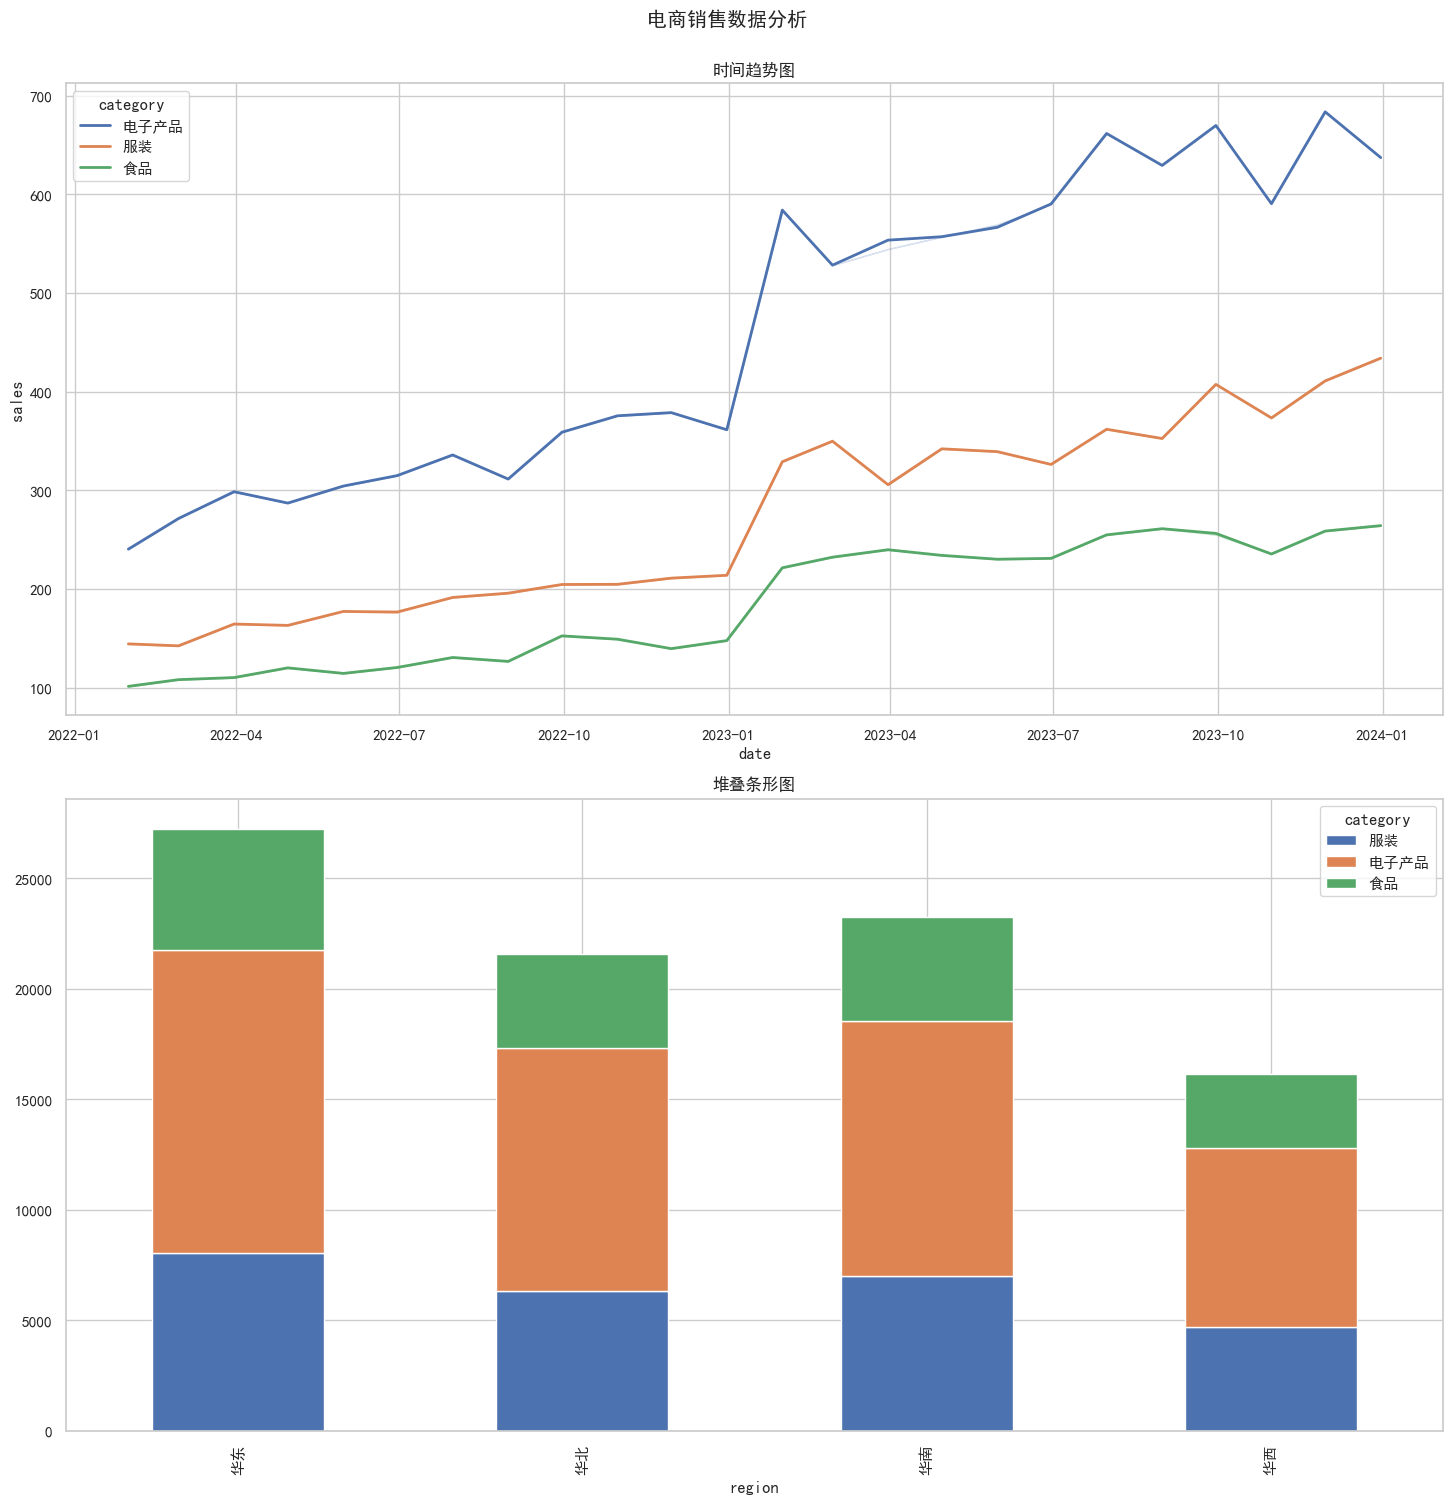

In [ ]:
fig, axs = plt.subplots(2, 1 ,figsize=(16,16))
ax1, ax2 = axs[0], axs[1]
sns.lineplot(data=df, x='date', y='sales', hue='category', errorbar=('ci', 0.95), linewidth=2, ax=ax1, err_style='band')
ax1.set_title("时间趋势图")

pivot_df = pd.pivot_table(data=df, values='sales', aggfunc='sum', index='region', columns='category')
pivot_df.plot(kind='bar',stacked=True, ax=ax2)
ax2.set_title("堆叠条形图")

plt.tight_layout(pad=5, h_pad=1)
plt.suptitle("电商销售数据分析")
plt.savefig(r"png/ecommerce_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# 题目 14：中文分词

处理含噪声的复杂文本（如含 URL、英文混杂的中文文本），实现精细化预处理（词性过滤、特殊字符清洗）及定制化词云生成。  

【任务】  

1.读取文件word.txt中的文本内容,含噪声的复杂文本（约 400 字，包含 URL、英文单词、特殊符号如 “@#”），保存在raw_text对象中（3 分）。  
2.使用正则表达式清洗文本：  
(1)去除 URL（如https://xxx）、邮箱、英文单词（保留中文）（8 分）。  
(2)去除特殊符号（@#￥%等）和多余空格（5 分）。  
3.分词与词性标注：使用jieba.posseg进行分词，仅保留名词（n开头）和动词（v开头）（8 分）。  
4.去停用词：结合通用停用词表 + 自定义专业停用词（如 “研究”“分析”），得到final_words（5 分）。  
5.词频统计与过滤：仅保留词频≥2 的词语，生成filtered_freq（5 分）。  
6.生成高级定制词云：  
(1)设置渐变色（可使用内置渐变色映射）（3 分）。  
(2)添加标题 “预处理后关键词云”，保存为"png/custom_wordcloud.png"（3 分）。  

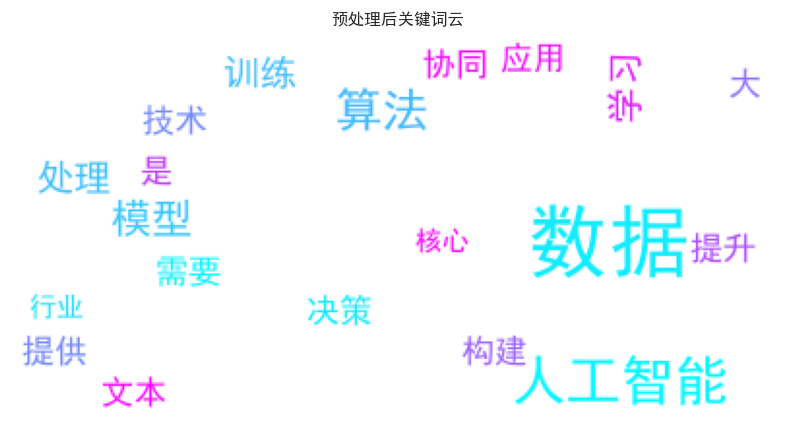

In [221]:
import wordcloud
import jieba
import re
import jieba
import matplotlib.pyplot as plt
from collections import Counter


plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

with open(r'text\word.txt', encoding='utf-8') as fp:
    raw_text = fp.read()


with open(r'text\word.txt', encoding='utf-8') as fp:
    raw_text = fp.read()


url_pat = r'https?://\S+\b'
email_pat = r'\b[a-zA-Z0-9_]+@\w+\.\w+\b'
word_pat = r'[A-Za-z,;!@，。？!（）、：]+'
tab_pat = r'\s+'

raw_text = re.sub(url_pat, "", raw_text)
raw_text = re.sub(email_pat, "", raw_text)
raw_text = re.sub(word_pat, "", raw_text)
text = re.sub(tab_pat, " ", raw_text)

words = [word for word, pos in jieba.posseg.cut(text) if pos.startswith(('n', 'v'))]

stop_words = ['的','了', '研究', '分析', '可']

final_words = [word for word in words if word not in stop_words]

filtered_freq = {word: frep for word, frep in Counter(final_words).items() if frep >= 2}

wc = wordcloud.WordCloud(
    font_path='simhei.ttf',
    max_words=20,
    background_color='white',
    colormap='cool'
)
word_cloud = wc.generate_from_frequencies(filtered_freq)

plt.figure(figsize=(10, 6))
plt.imshow(word_cloud)
plt.title("预处理后关键词云")
plt.axis('off')
plt.savefig(r'png/custom_wordcloud.png')
plt.show()

3.分词与词性标注：使用jieba.posseg进行分词，仅保留名词（n开头）和动词（v开头）（8 分）。  
4.去停用词：结合通用停用词表 + 自定义专业停用词（如 “研究”“分析”），得到final_words（5 分）。  
5.词频统计与过滤：仅保留词频≥2 的词语，生成filtered_freq（5 分）。  
6.生成高级定制词云：  
(1)设置渐变色（可使用内置渐变色映射）（3 分）。  
(2)添加标题 “预处理后关键词云”，保存为"png/custom_wordcloud.png"（3 分）。

# 题目 15：预测房价

使用线性回归模型预测房价，掌握单特征线性回归的建模流程、评估方法及结果可视化。  

【任务】  

1.加载house_price.csv文件中的房屋数据（含area（面积）和price（房价）列），可视化两者关系（散点图）（5 分）。  
2.划分训练集（70%）和测试集（30%），设置随机种子为 42（3 分）。  
3.训练简单线性回归模型（以area为特征预测price，不考虑超参数）（4 分）。  
4.在测试集上评估模型：计算 MSE（均方误差）和 R² 分数（4 分）。  
5.绘制回归线（训练集数据 + 预测线）（4 分）。  

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [224]:
df = pd.read_csv(r'csv/house_price.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    100 non-null    int64  
 1   price   100 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


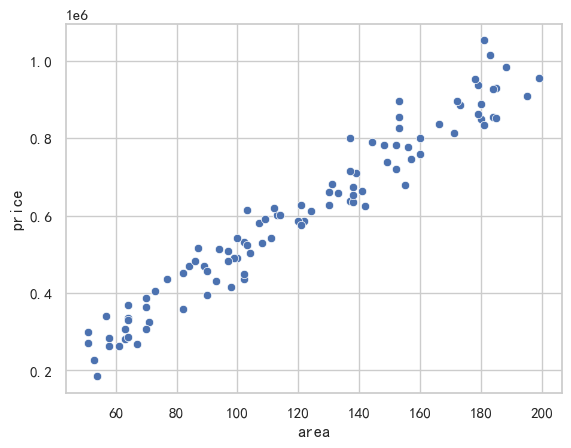

In [225]:
sns.scatterplot(data=df, x='area', y='price')

plt.show()

In [228]:
X = df[['area']]
Y = df['price']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X=x_train, y=y_train)
y_pred = model.predict(x_test)

print("MES：")
print(mean_squared_error(y_test, y_pred))
print("R2 score：")
print(r2_score(y_test, y_pred))

MES：
2796660074.586512
R2 score：
0.9456390458614289


In [237]:
type(y_pred)

numpy.ndarray

In [236]:
type(y_train.to_numpy())

numpy.ndarray

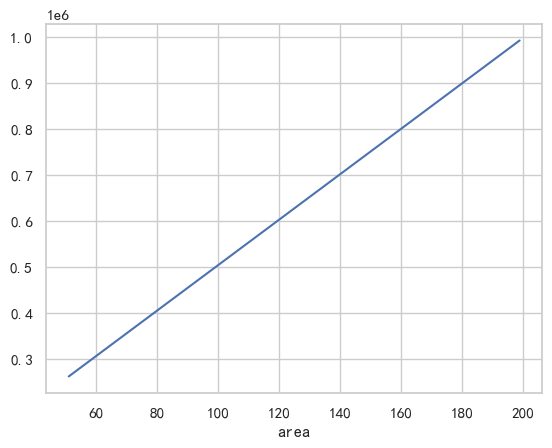

In [ ]:
y_data = np.concatenate([y_train.to_numpy(), y_pred])
sns.scatterplot(x=x_train['area'], y=model.predict(x_train),)
plt.show()

1.加载house_price.csv文件中的房屋数据（含area（面积）和price（房价）列），可视化两者关系（散点图）（5 分）。  
2.划分训练集（70%）和测试集（30%），设置随机种子为 42（3 分）。  
3.训练简单线性回归模型（以area为特征预测price，不考虑超参数）（4 分）。  
4.在测试集上评估模型：计算 MSE（均方误差）和 R² 分数（4 分）。  
5.绘制回归线（训练集数据 + 预测线）（4 分）。

# 题目16：预测用户流失

使用逻辑回归预测客户流失，掌握二分类模型构建、阈值调整及混淆矩阵分析。  

【任务】  

1.加载User_churn.csv文件中的客户数据（含tenure（在网时长）、monthly_fee（月费）、contract_type（0/1）（合约类型）、churn（是否流失，0/1））（2 分）。  
2.预处理：将contract_type转换为独热编码，划分训练集（70%）和测试集（30%）（7 分）。  
3.训练逻辑回归模型（预测churn，无需设置超参数）（5分）。     
4.计算测试集准确率并打印（4分）。  
5.生成混淆矩阵和分类报告并打印（6 分）。  
6.将分类阈值从 0.5 调整为 0.3，打印调整后的分类报告（6 分）。  

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder


plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [292]:
df = pd.read_csv(r'csv/User_churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         1000 non-null   int64  
 1   monthly_fee    1000 non-null   float64
 2   contract_type  1000 non-null   int64  
 3   churn          1000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 31.4 KB


In [293]:
coder = OneHotEncoder(sparse_output=False)
onehot_df = pd.DataFrame(coder.fit_transform(df[['contract_type']]), columns=coder.get_feature_names_out(['contract_type']))

df = pd.concat([df, onehot_df], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           1000 non-null   int64  
 1   monthly_fee      1000 non-null   float64
 2   contract_type    1000 non-null   int64  
 3   churn            1000 non-null   int64  
 4   contract_type_0  1000 non-null   float64
 5   contract_type_1  1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [294]:
x_train, x_test, y_train, y_test = train_test_split(df[['tenure', 'monthly_fee', 'contract_type_0', 'contract_type_1']], df['churn'], test_size=0.3, random_state=42)

model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("准确率")
print(accuracy_score(y_test, y_pred))
print("混淆矩阵")
print(confusion_matrix(y_test, y_pred))
print("分类报告")
print(classification_report(y_test, y_pred))

准确率
0.8633333333333333
混淆矩阵
[[248   7]
 [ 34  11]]
分类报告
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       255
           1       0.61      0.24      0.35        45

    accuracy                           0.86       300
   macro avg       0.75      0.61      0.64       300
weighted avg       0.84      0.86      0.84       300



In [295]:
x_train, x_test, y_train, y_test = train_test_split(df[['tenure', 'monthly_fee', 'contract_type_0', 'contract_type_1']], df['churn'], test_size=0.5, random_state=42)

model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("准确率")
print(accuracy_score(y_test, y_pred))
print("混淆矩阵")
print(confusion_matrix(y_test, y_pred))
print("分类报告")
print(classification_report(y_test, y_pred))

准确率
0.88
混淆矩阵
[[424   8]
 [ 52  16]]
分类报告
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       432
           1       0.67      0.24      0.35        68

    accuracy                           0.88       500
   macro avg       0.78      0.61      0.64       500
weighted avg       0.86      0.88      0.85       500



In [297]:
y_pred_proba = model.predict_proba(x_test)
y_pred = (y_pred_proba[:, 1] >= 0.3).astype(int)
print("分类报告")
print(classification_report(y_test, y_pred))

分类报告
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       432
           1       0.45      0.53      0.49        68

    accuracy                           0.85       500
   macro avg       0.69      0.71      0.70       500
weighted avg       0.86      0.85      0.85       500

